In [1]:
import os 
import numpy as np
import torch
import matplotlib.pyplot as plt
import cv2
from segment_anything import sam_model_registry, SamPredictor
from segment_anything.automatic_mask_generator import SamAutomaticMaskGenerator

In [2]:
IMAGE_PATH = 'images/truck.jpg'                
CHECKPOINT_PATH = "/scratch/tnguyen10/sam_vit_h_4b8939.pth"
MODEL_TYPE = "vit_h"                          # 'vit_h', 'vit_l', or 'vit_b'
USE_GPU = torch.cuda.is_available()
device = "cuda" if USE_GPU else "cpu"

MAX_MASKS = 10

OUT_DIR = "sam_auto_out"
os.makedirs(OUT_DIR, exist_ok=True)

In [3]:
# Load SAM model and create mask generator
sam = sam_model_registry[MODEL_TYPE](checkpoint=CHECKPOINT_PATH)
sam.to(device=device)

mask_generator = SamAutomaticMaskGenerator(
    model=sam,
    points_per_side=32,           # increase for more thorough masks (slower)
    pred_iou_thresh=0.88,         # filter low-quality masks
    stability_score_thresh=0.92,  # filter unstable masks
    crop_n_layers=1,              # add layers for larger images or more detail
    crop_n_points_downscale_factor=2,
    min_mask_region_area=100      # remove small stray masks
)

/home/tnguyen10/.conda/envs/gpu_env/lib/python3.10/site-packages/segment_anything/build_sam.py:105: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = torch.load(f)


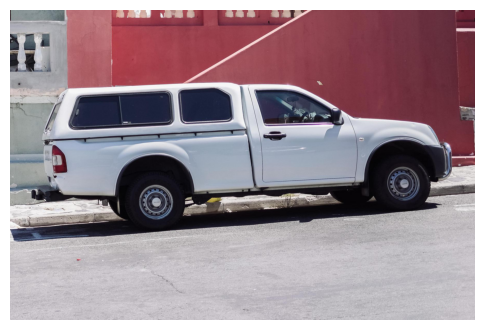

In [4]:
image_bgr = cv2.imread(IMAGE_PATH)
assert image_bgr is not None, f"Could not read image at {IMAGE_PATH}"
image = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)

# Show image
plt.figure(figsize=(6,6))
plt.imshow(image)
plt.axis('off')
plt.show()

In [5]:
# 4) Generate masks (list of dicts)
masks = mask_generator.generate(image)
masks = sorted(masks, key=lambda m: m['predicted_iou'], reverse=True)[:MAX_MASKS]
print(f"Generated {len(masks)} masks")

Generated 10 masks


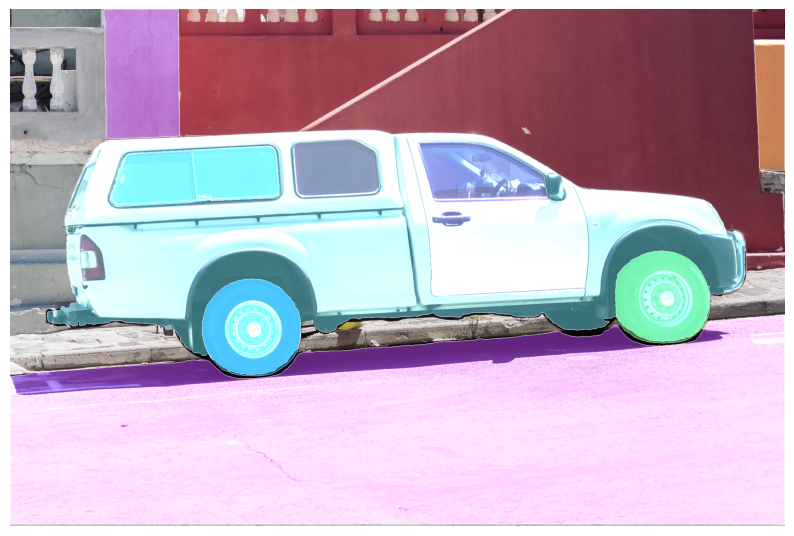

In [6]:
# 5) Visualize: overlay all masks with random colors
overlay = image.copy().astype(np.uint8)
alpha = 0.5
rand = np.random.RandomState(42)  # deterministic colors

for m in masks:
    color = rand.randint(0, 256, size=3, dtype=np.uint8)
    colored_mask = np.zeros_like(overlay)
    colored_mask[m["segmentation"]] = color
    overlay = cv2.addWeighted(overlay, 1.0, colored_mask, alpha, 0)

# Draw contours for visibility
for m in masks:
    seg = m["segmentation"].astype(np.uint8)
    contours, _ = cv2.findContours(seg, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    cv2.drawContours(overlay, contours, -1, (255, 255, 255), 1)

# 6) Show predicted masks
plt.figure(figsize=(10,10))
plt.imshow(overlay)
plt.axis('off')
plt.show()

# # 7) (Optional) Save each mask as a binary PNG and a colored preview
# for i, m in enumerate(masks):
#     seg = m["segmentation"].astype(np.uint8) * 255
#     mask_path = os.path.join(OUT_DIR, f"mask_{i:04d}.png")
#     cv2.imwrite(mask_path, seg)

#     preview = image.copy()
#     preview[seg == 0] = (preview[seg == 0] * 0.2).astype(preview.dtype)
#     preview_path = os.path.join(OUT_DIR, f"mask_{i:04d}_preview.png")
#     cv2.imwrite(preview_path, cv2.cvtColor(preview, cv2.COLOR_RGB2BGR))

# print("Done.")